<div style="font-size:30px;font-weight:700;color:#111827;padding-bottom:8px;margin:18px 0;">
PyTorch Autoencoder for Cyber Security Anomaly Detection
</div>

- Dataset: KDD Cup 1999 SA subset
- 설치: pip install scikit-learn pandas numpy matplotlib torch joblib

In [1]:
import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 기본 설정

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
device

device(type='cuda')

# KDD99 feature 설명

In [5]:
# ============================================================
# 1. KDD99 feature 설명
# ============================================================
# row 1개 = 네트워크 connection / flow 1건
# column 1개 = connection을 설명하는 feature
#
# label:
# - normal. = 정상
# - normal. 이외 = 공격 / 이상
#
# 이 예제에서는:
# - 0 = normal
# - 1 = anomaly

feature_descriptions = {
    "duration": "connection 지속 시간, 초 단위",
    "protocol_type": "프로토콜 종류. 예: tcp, udp, icmp",
    "service": "대상 네트워크 서비스. 예: http, smtp, ftp 등",
    "flag": (
        "connection 상태 요약값. TCP header의 raw flag 비트가 아니라 "
        "connection의 정상/오류 상태를 나타냄. 예: SF=정상 연결/종료, "
        "S0=연결 시도 후 응답 없음, REJ=연결 거절"
    ),
    "src_bytes": (
        "connection 단위에서 source에서 destination 방향으로 전송된 data byte 총합. "
        "row 1개는 패킷 1개가 아니라 connection/flow 1개"
    ),
    "dst_bytes": (
        "connection 단위에서 destination에서 source 방향으로 전송된 data byte 총합"
    ),
    "land": "source/destination IP와 port가 모두 같으면 1",
    "wrong_fragment": "잘못된 fragment 수",
    "urgent": "urgent packet 수",
    "hot": "보안상 민감한 동작 indicator 수",
    "num_failed_logins": "로그인 실패 횟수",
    "logged_in": "로그인 성공 여부",
    "num_compromised": "compromised condition 수",
    "root_shell": "root shell 획득 여부",
    "su_attempted": "su root 명령 시도 여부",
    "num_root": "root access 수",
    "num_file_creations": "파일 생성 횟수",
    "num_shells": "shell prompt 획득 횟수",
    "num_access_files": "access control file 접근 횟수",
    "num_outbound_cmds": "outbound command 수",
    "is_host_login": "host login 여부",
    "is_guest_login": "guest login 여부",
    "count": "최근 2초 동안 같은 destination host로의 connection 수",
    "srv_count": "최근 2초 동안 같은 service로의 connection 수",
    "serror_rate": "SYN error connection 비율",
    "srv_serror_rate": "같은 service 대상 SYN error 비율",
    "rerror_rate": "REJ error connection 비율",
    "srv_rerror_rate": "같은 service 대상 REJ error 비율",
    "same_srv_rate": "같은 service connection 비율",
    "diff_srv_rate": "다른 service connection 비율",
    "srv_diff_host_rate": "같은 service 중 다른 host로 향한 비율",
    "dst_host_count": "최근 100개 connection 중 같은 destination host 수",
    "dst_host_srv_count": "최근 100개 connection 중 같은 destination host와 service 수",
    "dst_host_same_srv_rate": "destination host 기준 같은 service 비율",
    "dst_host_diff_srv_rate": "destination host 기준 다른 service 비율",
    "dst_host_same_src_port_rate": "destination host 기준 같은 source port 비율",
    "dst_host_srv_diff_host_rate": "destination host/service 기준 다른 host 비율",
    "dst_host_serror_rate": "destination host 기준 SYN error 비율",
    "dst_host_srv_serror_rate": "destination host/service 기준 SYN error 비율",
    "dst_host_rerror_rate": "destination host 기준 REJ error 비율",
    "dst_host_srv_rerror_rate": "destination host/service 기준 REJ error 비율",
}

In [6]:
flag_descriptions = {
    "SF": "정상적으로 연결되고 정상적으로 종료됨",
    "S0": "연결 시도는 있었지만 응답이 없음",
    "S1": "연결은 되었지만 종료가 관찰되지 않음",
    "S2": "연결 후 originator가 종료를 시도했지만 responder 응답이 없음",
    "S3": "연결 후 responder가 종료를 시도했지만 originator 응답이 없음",
    "REJ": "연결 시도가 거절됨",
    "RSTO": "연결 후 originator가 RST로 강제 종료",
    "RSTR": "responder가 RST로 강제 종료",
    "OTH": "SYN 없이 중간 트래픽만 관찰됨",
}

# 시각화 함수

In [7]:
def plot_label_distribution(y_values, title):
    counts = pd.Series(y_values).value_counts().reindex([0, 1], fill_value=0)

    plt.figure(figsize=(6, 4))
    plt.bar(["normal", "anomaly"], counts.values)
    plt.title(title)
    plt.xlabel("Label")
    plt.ylabel("Count")

    for i, v in enumerate(counts.values):
        plt.text(i, v, f"{v:,}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

In [8]:
def plot_loss_history(train_losses, val_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="train normal loss")
    plt.plot(val_losses, label="validation normal loss")
    plt.title("Autoencoder Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
def plot_confusion_matrix(cm, title):
    labels = ["normal", "anomaly"]

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], labels)
    plt.yticks([0, 1], labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [10]:
def plot_latent_space_2d(Z, y_true, title):
    """
    Encoder의 latent vector 중 앞의 2개 차원을 사용해 시각화합니다.

    latent_dim이 2 이상이어야 합니다.
    이 그림은 모델 성능 평가용이라기보다,
    encoder가 만든 저차원 표현을 이해하기 위한 용도입니다.
    """
    if Z.shape[1] < 2:
        print("latent_dim이 2보다 작아서 2D 시각화를 할 수 없습니다.")
        return

    y_true = np.asarray(y_true)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        Z[y_true == 0, 0],
        Z[y_true == 0, 1],
        s=8,
        alpha=0.5,
        label="normal"
    )
    plt.scatter(
        Z[y_true == 1, 0],
        Z[y_true == 1, 1],
        s=8,
        alpha=0.8,
        label="anomaly"
    )
    plt.title(title)
    plt.xlabel("latent_0")
    plt.ylabel("latent_1")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 데이터 다운로드

In [93]:
kdd = fetch_kddcup99(
    subset="SA",
    percent10=True,
    as_frame=True,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [94]:
X = kdd.data.copy()
y_raw = pd.Series(kdd.target)

In [95]:
# label이 bytes 형태일 수 있으므로 문자열로 변환
y_raw = y_raw.map(lambda v: v.decode("utf-8") if isinstance(v, bytes) else str(v))

In [96]:
# normal. 이면 0, 그 외는 1
y = (y_raw != "normal.").astype(int)

In [97]:
# object 컬럼의 bytes 값을 문자열로 변환
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = X[col].map(lambda v: v.decode("utf-8") if isinstance(v, bytes) else v)

# 데이터 로딩 직후 실제 데이터 확인

In [98]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [99]:
# 데이터 크기
print("X shape:", X.shape)
print("y shape:", y.shape)
print("row 개수:", f"{X.shape[0]:,}")
print("feature 개수:", X.shape[1])

X shape: (100655, 41)
y shape: (100655,)
row 개수: 100,655
feature 개수: 41


In [100]:
# 실제 데이터 앞부분 10개
X.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,http,SF,241,510,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,14,14,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
1,0,tcp,smtp,SF,3225,392,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,120,138,0.64,0.03,0.01,0.01,0.0,0.0,0.0,0.0
2,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,206,3,0.0,0.0,1.0,1.0,0.01,0.07,0.00,255,3,0.01,0.08,0.00,0.00,0.0,0.0,1.0,1.0
3,0,tcp,http,SF,235,2895,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,46,0.0,0.0,0.0,0.0,1.00,0.00,0.13,32,255,1.00,0.00,0.03,0.02,0.0,0.0,0.0,0.0
4,0,udp,domain_u,SF,35,95,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,249,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0
5,0,udp,private,SF,105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,251,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0
6,0,tcp,http,SF,253,33119,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,228,0.89,0.02,0.00,0.00,0.0,0.0,0.0,0.0
7,0,udp,domain_u,SF,43,127,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,87,0.0,0.0,0.0,0.0,1.00,0.00,0.02,255,205,0.80,0.02,0.00,0.00,0.0,0.0,0.0,0.0
8,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,1,0.00,0.40,0.80,0.00,0.0,0.0,0.0,0.0
9,5749,udp,other,SF,145,105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,1,0.00,0.62,0.94,0.00,0.0,0.0,0.0,0.0


In [19]:
# label 앞부분 10개
pd.DataFrame({
    "original_label": y_raw.head(10),
    "binary_label": y.head(10)
})

,original_label,binary_label
0,normal.,0
1,normal.,0
2,neptune.,1
3,normal.,0
4,normal.,0
5,normal.,0
6,normal.,0
7,normal.,0
8,normal.,0
9,normal.,0


In [102]:
# label 앞부분 10개
pd.DataFrame({
    "original_label": y_raw.head(5),
    "binary_label": y.head(10)
})

,original_label,binary_label
0,normal.,0
1,normal.,0
2,neptune.,1
3,normal.,0
4,normal.,0
5,NaN,0
6,NaN,0
7,NaN,0
8,NaN,0
9,NaN,0


In [20]:
# 정상 / 이상 분포
print(y.value_counts().rename({0: "normal", 1: "anomaly"}))
print("---")
print(y.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))

labels
normal     97278
anomaly     3377
Name: count, dtype: int64
---
labels
normal     0.96645
anomaly    0.03355
Name: proportion, dtype: float64


In [21]:
# feature 설명
for i, col in enumerate(X.columns, start=1):
    print(f"{i:02d}. {col}: {feature_descriptions.get(col, '설명 미등록')}")

01. duration: connection 지속 시간, 초 단위
02. protocol_type: 프로토콜 종류. 예: tcp, udp, icmp
03. service: 대상 네트워크 서비스. 예: http, smtp, ftp 등
04. flag: connection 상태 요약값. TCP header의 raw flag 비트가 아니라 connection의 정상/오류 상태를 나타냄. 예: SF=정상 연결/종료, S0=연결 시도 후 응답 없음, REJ=연결 거절
05. src_bytes: connection 단위에서 source에서 destination 방향으로 전송된 data byte 총합. row 1개는 패킷 1개가 아니라 connection/flow 1개
06. dst_bytes: connection 단위에서 destination에서 source 방향으로 전송된 data byte 총합
07. land: source/destination IP와 port가 모두 같으면 1
08. wrong_fragment: 잘못된 fragment 수
09. urgent: urgent packet 수
10. hot: 보안상 민감한 동작 indicator 수
11. num_failed_logins: 로그인 실패 횟수
12. logged_in: 로그인 성공 여부
13. num_compromised: compromised condition 수
14. root_shell: root shell 획득 여부
15. su_attempted: su root 명령 시도 여부
16. num_root: root access 수
17. num_file_creations: 파일 생성 횟수
18. num_shells: shell prompt 획득 횟수
19. num_access_files: access control file 접근 횟수
20. num_outbound_cmds: outbound command 수
21. is_host_login: host login 여부
22. is_guest_login: g

In [22]:
# flag 값 의미
for k, v in flag_descriptions.items():
    print(f"{k}: {v}")

SF: 정상적으로 연결되고 정상적으로 종료됨
S0: 연결 시도는 있었지만 응답이 없음
S1: 연결은 되었지만 종료가 관찰되지 않음
S2: 연결 후 originator가 종료를 시도했지만 responder 응답이 없음
S3: 연결 후 responder가 종료를 시도했지만 originator 응답이 없음
REJ: 연결 시도가 거절됨
RSTO: 연결 후 originator가 RST로 강제 종료
RSTR: responder가 RST로 강제 종료
OTH: SYN 없이 중간 트래픽만 관찰됨


In [103]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Categorical features:", categorical_cols)
print("Numeric feature count:", len(numeric_cols))

Categorical features: ['protocol_type', 'service', 'flag']
Numeric feature count: 38


In [104]:
# category feature 값 확인
for col in categorical_cols:
    print(f"\n[{col}] unique 값 개수:", X[col].nunique())
    print(X[col].value_counts())


[protocol_type] unique 값 개수: 3
protocol_type
tcp     77758
udp     19188
icmp     3709
Name: count, dtype: int64

[service] unique 값 개수: 49
service
http           61902
smtp            9598
private         8240
domain_u        5862
other           5646
ftp_data        3804
ecr_i           2757
urp_i            537
finger           472
eco_i            398
ntp_u            380
ftp              377
auth             220
telnet           220
pop_3             81
time              52
IRC               42
urh_i             14
X11                9
domain             6
ssh                3
gopher             2
csnet_ns           2
echo               2
rje                2
tim_i              2
remote_job         2
systat             2
netbios_dgm        1
uucp_path          1
discard            1
name               1
mtp                1
netbios_ssn        1
nntp               1
ctf                1
courier            1
nnsp               1
sql_net            1
vmnet              1
supdup     

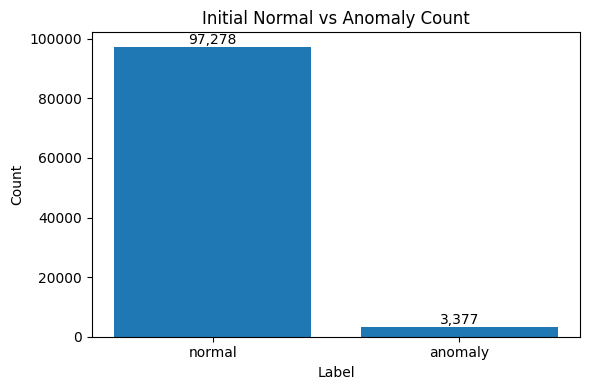

In [25]:
plot_label_distribution(y, "Initial Normal vs Anomaly Count")

# Train / Validation / Test 분리

In [105]:
# 전체 데이터:
# - train      : 60%
# - validation : 20%
# - test       : 20%
#
# y_raw도 같이 나누는 이유:
# - 모델 학습에는 쓰지 않음
# - 나중에 어떤 공격 유형인지 사후 분석하기 위해 보관

In [27]:
X_temp, X_test, y_temp, y_test, y_raw_temp, y_raw_test = train_test_split(
    X,
    y,
    y_raw,
    test_size=0.20, # X_temp = 0.8, X_test = 0.2 로 적용됨
    stratify=y,
    random_state=RANDOM_STATE
)

In [28]:
X_train_all, X_val, y_train_all, y_val, y_raw_train, y_raw_val = train_test_split(
    X_temp,
    y_temp,
    y_raw_temp,
    test_size=0.25, # X_temp의 값에서 75%, test_size = 25%
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [106]:
# Train / Validation / Test 분리 결과
print("X_train_all:", X_train_all.shape)
print("X_val      :", X_val.shape)
print("X_test     :", X_test.shape)

X_train_all: (60393, 41)
X_val      : (20131, 41)
X_test     : (20131, 41)


In [107]:
print("Train label 비율")
print(y_train_all.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))

print("\nValidation label 비율")
print(y_val.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))

print("\nTest label 비율")
print(y_test.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))

Train label 비율
labels
normal     0.966437
anomaly    0.033563
Name: proportion, dtype: float64

Validation label 비율
labels
normal     0.96647
anomaly    0.03353
Name: proportion, dtype: float64

Test label 비율
labels
normal     0.96647
anomaly    0.03353
Name: proportion, dtype: float64


# 정상 데이터만 학습에 사용

In [108]:
# Autoencoder는 정상 데이터를 자기 자신으로 복원하도록 학습합니다.
#
# 정상 데이터만 학습했으므로:
# - 정상 데이터는 잘 복원됨
# - 이상 데이터는 잘 복원되지 않을 가능성이 큼
# - reconstruction error가 크면 anomaly로 판단

In [109]:
X_train_normal = X_train_all[y_train_all == 0]  # 0 : 정상적인 데이터만 사용한다.
X_val_normal = X_val[y_val == 0]

In [33]:
# 실습 속도를 위한 샘플링
max_train_size = 100_000

In [34]:
if len(X_train_normal) > max_train_size:
    X_train_normal = X_train_normal.sample(
        n=max_train_size,
        random_state=RANDOM_STATE
    )

print("[+] Autoencoder 학습용 정상 데이터")
print("X_train_normal:", X_train_normal.shape)
print("X_val_normal  :", X_val_normal.shape)

[+] Autoencoder 학습용 정상 데이터
X_train_normal: (58366, 41)
X_val_normal  : (19456, 41)


# 전처리

In [35]:
# PyTorch 모델은 숫자 tensor만 입력으로 받을 수 있습니다.
#
# categorical feature:
# - protocol_type, service, flag
# - OneHotEncoder로 숫자화
#
# numeric feature:
# - StandardScaler로 scaling
#
# 중요:
# - preprocessor는 X_train_normal에만 fit합니다.
# - validation/test는 transform만 합니다.
# - 실제 운영에서 미래 데이터를 처리하는 방식과 같습니다.

In [36]:
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", onehot, categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

In [37]:
# OneHotEncoder는 train 정상 데이터에서 category 목록을 학습하고, StandardScaler는 train 정상 데이터의 숫자 feature 평균과 표준편차를 학습합니다.
X_train_normal_pre = preprocess.fit_transform(X_train_normal)

In [38]:
X_val_pre = preprocess.transform(X_val) # 정상과 이상이 모두 섞인 validation 데이터. threshold 결정과 validation 성능 평가에 사용합니다.
X_val_normal_pre = preprocess.transform(X_val_normal) # validation 중 정상 데이터만 모은 것. 학습 중 early stopping용 validation loss에 사용
X_test_pre = preprocess.transform(X_test) # 실제 미래 데이터처럼 예측. 마지막에만 성능 평가

In [39]:
X_train_normal_pre = X_train_normal_pre.astype("float32")
X_val_pre = X_val_pre.astype("float32")
X_val_normal_pre = X_val_normal_pre.astype("float32")
X_test_pre = X_test_pre.astype("float32")

In [40]:
# 전처리 후 데이터 크기
print("X_train_normal_pre:", X_train_normal_pre.shape)
print("X_val_normal_pre  :", X_val_normal_pre.shape)
print("X_val_pre         :", X_val_pre.shape)
print("X_test_pre        :", X_test_pre.shape)

X_train_normal_pre: (58366, 72)
X_val_normal_pre  : (19456, 72)
X_val_pre         : (20131, 72)
X_test_pre        : (20131, 72)


In [41]:
input_dim = X_train_normal_pre.shape[1]
input_dim

72

# PyTorch Dataset / DataLoader 생성

In [42]:
batch_size = 256

In [43]:
train_tensor = torch.tensor(X_train_normal_pre, dtype=torch.float32)
val_normal_tensor = torch.tensor(X_val_normal_pre, dtype=torch.float32)

In [44]:
train_dataset = TensorDataset(train_tensor, train_tensor)
val_normal_dataset = TensorDataset(val_normal_tensor, val_normal_tensor)

In [45]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_normal_loader = DataLoader(val_normal_dataset, batch_size=batch_size, shuffle=False)

# Encoder / Decoder / Autoencoder 모델 분리 정의

In [46]:
# 목적:
# - Autoencoder 전체는 이상탐지 학습에 사용
# - Encoder는 나중에 차원 축소 / feature extraction 용도로 따로 사용
# - Decoder는 latent vector를 원래 feature 공간으로 복원
#
# 구조:
#
# input feature vector
#        ↓
#     Encoder
#        ↓
# latent vector
#        ↓
#     Decoder
#        ↓
# reconstructed input
#
# Autoencoder = Encoder + Decoder

In [47]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, latent_dim),
            nn.ReLU()
        )

    def forward(self, x):
        z = self.net(x)
        return z

In [48]:
class Decoder(nn.Module):
    def __init__(self, output_dim, latent_dim=16):
        super().__init__()

        self.output_dim = output_dim
        self.latent_dim = latent_dim

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, output_dim)
        )

    def forward(self, z):
        reconstructed = self.net(z)
        return reconstructed

In [49]:
class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

In [50]:
# latent_dim:
# - Encoder가 만드는 저차원 표현의 차원 수
# - 16이면 고차원 one-hot feature를 16차원 latent vector로 압축
# - 시각화 목적이면 2로 설정할 수도 있음
# - 일반적으로는 8, 16, 32 등을 실험
latent_dim = 16

In [51]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(output_dim=input_dim, latent_dim=latent_dim).to(device)
autoencoder = Autoencoder(encoder=encoder, decoder=decoder).to(device)

In [52]:
# Loss function
criterion = nn.MSELoss()

# optimizer는 autoencoder 전체 파라미터를 학습합니다.
# 즉, encoder와 decoder가 함께 학습됩니다.
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

In [53]:
# Encoder 구조
print(encoder)

Encoder(
  (net): Sequential(
    (0): Linear(in_features=72, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=16, bias=True)
    (8): ReLU()
  )
)


In [54]:
# Decoder 구조
print(decoder)

Decoder(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=72, bias=True)
  )
)


In [55]:
# Autoencoder 구조
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=72, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=32, bias=True)
      (6): ReLU()
      (7): Linear(in_features=32, out_features=16, bias=True)
      (8): ReLU()
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=16, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=128, bias=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=72, bias=True)
    )
  )
)


# 학습 함수

In [56]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_count = 0

    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        current_batch_size = batch_x.size(0)
        total_loss += loss.item() * current_batch_size
        total_count += current_batch_size

    return total_loss / total_count

In [57]:
def evaluate_loss(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            current_batch_size = batch_x.size(0)
            total_loss += loss.item() * current_batch_size
            total_count += current_batch_size

    return total_loss / total_count

# 모델 학습

In [58]:
# Autoencoder 학습:
# - 입력:  X_train_normal_pre
# - 정답:  X_train_normal_pre
#
# 즉, 정상 데이터를 자기 자신으로 복원하도록 학습합니다.
#
# Early stopping:
# - validation normal loss가 좋아지지 않으면 학습 중단
# - 과적합을 줄이는 목적

In [59]:
epochs = 100
patience = 10

In [60]:
best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

In [61]:
train_losses = []
val_losses = []

In [62]:
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model=autoencoder,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss = evaluate_loss(
        model=autoencoder,
        data_loader=val_normal_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch:02d}/{epochs}] "
        f"train_loss={train_loss:.6f} "
        f"val_normal_loss={val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(autoencoder.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch [01/100] train_loss=0.348661 val_normal_loss=0.196994
Epoch [02/100] train_loss=0.222007 val_normal_loss=0.155962
Epoch [03/100] train_loss=0.186330 val_normal_loss=0.164505
Epoch [04/100] train_loss=0.163816 val_normal_loss=0.131140
Epoch [05/100] train_loss=0.135093 val_normal_loss=0.100040
Epoch [06/100] train_loss=0.139658 val_normal_loss=0.110517
Epoch [07/100] train_loss=0.117446 val_normal_loss=0.092575
Epoch [08/100] train_loss=0.099723 val_normal_loss=0.093537
Epoch [09/100] train_loss=0.123639 val_normal_loss=0.077381
Epoch [10/100] train_loss=0.101944 val_normal_loss=0.057720
Epoch [11/100] train_loss=0.084493 val_normal_loss=0.059547
Epoch [12/100] train_loss=0.090300 val_normal_loss=0.065047
Epoch [13/100] train_loss=0.099785 val_normal_loss=0.068944
Epoch [14/100] train_loss=0.095162 val_normal_loss=0.058713
Epoch [15/100] train_loss=0.075158 val_normal_loss=0.070345
Epoch [16/100] train_loss=0.061382 val_normal_loss=0.048610
Epoch [17/100] train_loss=0.052712 val_n

In [63]:
# 가장 validation loss가 좋았던 autoencoder weight 복원
autoencoder.load_state_dict(best_model_state)

<All keys matched successfully>

In [64]:
# autoencoder 안에 들어 있는 encoder, decoder도 함께 복원됩니다.
encoder = autoencoder.encoder
decoder = autoencoder.decoder

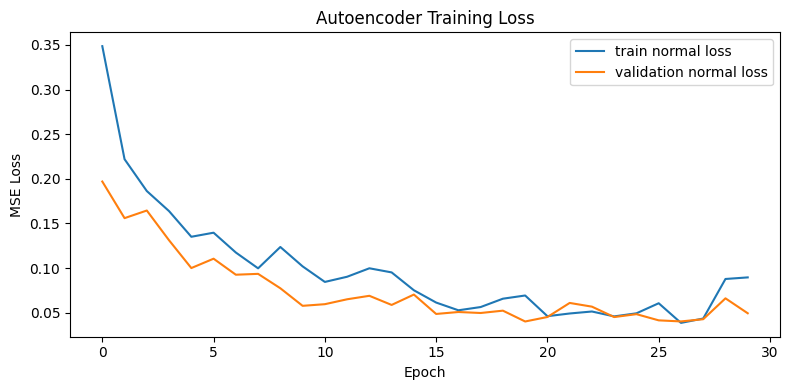

In [65]:
plot_loss_history(train_losses, val_losses)

# Reconstruction error 계산 함수

In [66]:
# reconstruction error:
# - 원본 입력과 복원 출력의 차이
# - 값이 클수록 복원이 잘 안 됨
# - 정상 패턴에서 벗어났을 가능성이 큼

In [67]:
def reconstruction_error(model, X_array, device, batch_size=1024):
    model.eval()

    dataset = TensorDataset(torch.tensor(X_array, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    errors = []

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)

            outputs = model(batch_x)

            # sample별 MSE
            batch_errors = torch.mean((batch_x - outputs) ** 2, dim=1)

            errors.append(batch_errors.cpu().numpy())

    return np.concatenate(errors)

In [68]:
train_error = reconstruction_error(autoencoder, X_train_normal_pre, device)
val_error = reconstruction_error(autoencoder, X_val_pre, device)

In [69]:
print("[+] Train normal reconstruction error 요약")
print(pd.Series(train_error).describe())
print("---")
print("[+] Validation reconstruction error 요약")
print(pd.Series(val_error).describe())

[+] Train normal reconstruction error 요약
count    58366.000000
mean         0.041652
std          1.957910
min          0.000274
25%          0.001087
50%          0.003590
75%          0.012671
max        310.854553
dtype: float64
---
[+] Validation reconstruction error 요약
count    20131.000000
mean         0.268425
std          2.736973
min          0.000282
25%          0.001147
50%          0.003974
75%          0.015168
max        117.941681
dtype: float64


# Validation 데이터로 threshold 결정

In [70]:
# threshold:
# - reconstruction_error >= threshold 이면 anomaly
# - reconstruction_error < threshold 이면 normal
#
# 여기서는 validation F1-score가 가장 높은 threshold를 선택합니다.

In [71]:
def find_best_threshold_by_f1(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    precision_t = precision[:-1]
    recall_t = recall[:-1]

    f1 = 2 * precision_t * recall_t / (precision_t + recall_t + 1e-12)

    best_idx = np.argmax(f1)

    return {
        "threshold": thresholds[best_idx],
        "precision": precision_t[best_idx],
        "recall": recall_t[best_idx],
        "f1": f1[best_idx]
    }

In [72]:
threshold_result = find_best_threshold_by_f1(y_val, val_error)
threshold = threshold_result["threshold"]

In [73]:
# Validation에서 선택한 threshold
print(f"threshold : {threshold:.8f}")
print(f"precision : {threshold_result['precision']:.4f}")
print(f"recall    : {threshold_result['recall']:.4f}")
print(f"f1        : {threshold_result['f1']:.4f}")

threshold : 0.25280425
precision : 0.8043
recall    : 0.9867
f1        : 0.8862


# Validation 성능 확인

In [74]:
val_pred = (val_error >= threshold).astype(int)

In [75]:
# Classification Report
print(classification_report(
    y_val,
    val_pred,
    target_names=["normal", "anomaly"],
    digits=4
))

              precision    recall  f1-score   support

      normal     0.9995    0.9917    0.9956     19456
     anomaly     0.8043    0.9867    0.8862       675

    accuracy                         0.9915     20131
   macro avg     0.9019    0.9892    0.9409     20131
weighted avg     0.9930    0.9915    0.9919     20131



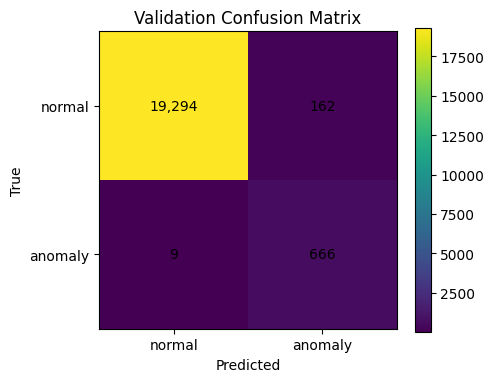

In [76]:
val_cm = confusion_matrix(y_val, val_pred)
plot_confusion_matrix(
    val_cm,
    title="Validation Confusion Matrix"
)

# 실제 application 예측 함수

In [77]:
# 실제 운영에서는 label이 없습니다.
# 새 데이터 X_new만 들어옵니다.
#
# 함수 출력:
# - reconstruction_error
# - predicted_label
# - predicted_class

In [78]:
def predict_new_connections(autoencoder, preprocessor, X_new, threshold, device):
    X_new_pre = preprocessor.transform(X_new).astype("float32")

    scores = reconstruction_error(
        model=autoencoder,
        X_array=X_new_pre,
        device=device
    )

    pred_label = (scores >= threshold).astype(int)
    pred_class = np.where(pred_label == 1, "anomaly", "normal")

    return pd.DataFrame({
        "reconstruction_error": scores,
        "predicted_label": pred_label,
        "predicted_class": pred_class
    })

# Test 데이터를 미래에 들어온 application 데이터라고 가정

In [79]:
# 여기서는 y_test를 사용하지 않습니다.
# 실제 운영처럼 X_test만 보고 예측합니다.
application_predictions = predict_new_connections(
    autoencoder=autoencoder,
    preprocessor=preprocess,
    X_new=X_test,
    threshold=threshold,
    device=device
)

In [80]:
# 미래 데이터 예측 결과 앞부분 20개
application_predictions.head(20)

,reconstruction_error,predicted_label,predicted_class
0,0.004681,0,normal
1,0.002436,0,normal
2,0.003873,0,normal
3,0.001128,0,normal
4,0.009008,0,normal
5,0.000454,0,normal
6,0.001177,0,normal
7,0.001257,0,normal
8,0.000907,0,normal
9,25.766665,1,anomaly


In [81]:
# 예측 결과 개수
print(application_predictions["predicted_class"].value_counts())

predicted_class
normal     19267
anomaly      864
Name: count, dtype: int64


In [82]:
# 원본 test 데이터와 예측 결과를 합칩니다.
app_result = X_test.reset_index(drop=True).copy()
app_result = pd.concat(
    [app_result, application_predictions.reset_index(drop=True)],
    axis=1
)

important_cols = [
    "predicted_class",
    "predicted_label",
    "reconstruction_error",
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "same_srv_rate",
    "dst_host_count",
    "dst_host_srv_count"
]

important_cols = [c for c in important_cols if c in app_result.columns]

In [83]:
app_result.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,reconstruction_error,predicted_label,predicted_class
0,0,tcp,http,SF,355,922,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,19,39,0.0,0.0,0.0,0.0,1.0,0.0,0.05,169,254,1.00,0.00,0.01,0.02,0.01,0.00,0.0,0.0,0.004681,0,normal
1,0,tcp,http,SF,331,377,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,35,37,0.0,0.0,0.0,0.0,1.0,0.0,0.05,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.002436,0,normal
2,0,tcp,http,SF,202,1385,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,28,29,0.0,0.0,0.0,0.0,1.0,0.0,0.07,28,255,1.00,0.00,0.04,0.03,0.00,0.00,0.0,0.0,0.003873,0,normal
3,0,tcp,http,SF,323,434,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,19,30,0.0,0.0,0.0,0.0,1.0,0.0,0.13,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.001128,0,normal
4,4,tcp,smtp,SF,2430,338,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,0.0,0.0,0.0,0.0,1.0,0.0,1.00,90,183,0.72,0.04,0.01,0.01,0.00,0.01,0.0,0.0,0.009008,0,normal


In [84]:
# Application 결과 예시
app_result[important_cols].head(20)

,predicted_class,predicted_label,reconstruction_error,duration,protocol_type,service,flag,src_bytes,dst_bytes,count,srv_count,serror_rate,same_srv_rate,dst_host_count,dst_host_srv_count
0,normal,0,0.004681,0,tcp,http,SF,355,922,19,39,0.0,1.00,169,254
1,normal,0,0.002436,0,tcp,http,SF,331,377,35,37,0.0,1.00,255,255
2,normal,0,0.003873,0,tcp,http,SF,202,1385,28,29,0.0,1.00,28,255
3,normal,0,0.001128,0,tcp,http,SF,323,434,19,30,0.0,1.00,255,255
4,normal,0,0.009008,4,tcp,smtp,SF,2430,338,1,2,0.0,1.00,90,183
5,normal,0,0.000454,0,tcp,http,SF,348,915,7,7,0.0,1.00,255,255
6,normal,0,0.001177,0,tcp,http,SF,235,8215,3,3,0.0,1.00,3,255
7,normal,0,0.001257,0,tcp,http,SF,325,346,9,9,0.0,1.00,76,255
8,normal,0,0.000907,0,udp,private,SF,105,146,1,1,0.0,1.00,255,229
9,anomaly,1,25.766665,0,tcp,private,S0,0,0,140,18,1.0,0.13,255,18


In [85]:
# anomaly score가 높은 상위 alert
top_alerts = app_result.sort_values("reconstruction_error", ascending=False).head(20)
top_alerts[important_cols]

,predicted_class,predicted_label,reconstruction_error,duration,protocol_type,service,flag,src_bytes,dst_bytes,count,srv_count,serror_rate,same_srv_rate,dst_host_count,dst_host_srv_count
19519,anomaly,1,121.692924,11867,tcp,telnet,SF,512,49567,1,1,0.00,1.00,56,10
14729,anomaly,1,102.427368,5046,tcp,ftp_data,SF,0,5134218,1,1,0.00,1.00,255,64
16295,anomaly,1,91.502235,10039,tcp,telnet,SF,5850,12602,1,1,0.00,1.00,20,5
5337,anomaly,1,70.867554,13368,tcp,telnet,SF,2987,58843,1,1,0.00,1.00,127,11
3118,anomaly,1,43.025032,0,tcp,other,S0,0,0,511,1,0.11,0.00,255,1
5880,anomaly,1,34.013847,0,tcp,private,S0,0,0,300,20,1.00,0.07,255,20
11818,anomaly,1,33.827744,0,tcp,private,S0,0,0,297,19,1.00,0.06,255,18
19351,anomaly,1,33.611671,0,tcp,private,S0,0,0,294,18,1.00,0.06,255,18
18512,anomaly,1,33.436855,0,tcp,private,S0,0,0,293,14,1.00,0.05,255,13
2985,anomaly,1,33.133728,0,tcp,private,S0,0,0,286,19,1.00,0.07,255,19


# Test label은 마지막 평가용으로만 사용

In [86]:
# 실제 application에서는 y_test가 없습니다.
# 하지만 예제 데이터에는 정답 label이 있으므로 마지막에만 평가합니다.

test_error = application_predictions["reconstruction_error"].values
test_pred = application_predictions["predicted_label"].values

In [87]:
# Test 성능 평가
# 실제 application에서는 이 단계의 정답 label이 없습니다.
# 여기서는 예제 검증을 위해서만 y_test를 사용합니다.

print("\nClassification Report")
print(classification_report(
    y_test,
    test_pred,
    target_names=["normal", "anomaly"],
    digits=4
))


Classification Report
              precision    recall  f1-score   support

      normal     0.9997    0.9900    0.9949     19456
     anomaly     0.7755    0.9926    0.8707       675

    accuracy                         0.9901     20131
   macro avg     0.8876    0.9913    0.9328     20131
weighted avg     0.9922    0.9901    0.9907     20131



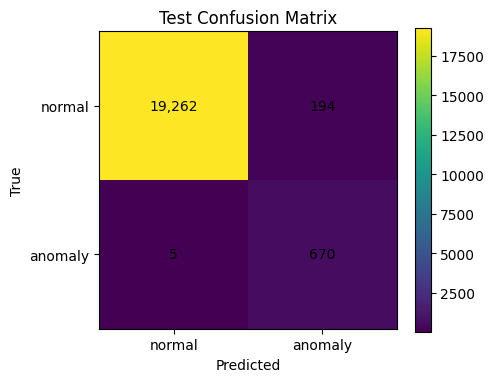

In [88]:
test_cm = confusion_matrix(y_test, test_pred)
plot_confusion_matrix(
    test_cm,
    title="Test Confusion Matrix"
)

# Encoder만 사용해서 latent feature 추출

In [89]:
# 이 함수는 anomaly detection이 아니라 차원 축소 / feature extraction 용도입니다.
#
# 입력:
# - encoder: 학습된 encoder 모델
# - X_array: 전처리 완료된 numpy array
#
# 출력:
# - latent vector
# - shape: (sample 수, latent_dim)
def encode_features(encoder, X_array, device, batch_size=1024):
    encoder.eval()

    dataset = TensorDataset(torch.tensor(X_array, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    latent_vectors = []

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)

            z = encoder(batch_x)

            latent_vectors.append(z.cpu().numpy())

    return np.concatenate(latent_vectors, axis=0)

In [90]:
Z_train_normal = encode_features(encoder=encoder, X_array=X_train_normal_pre, device=device)
Z_val = encode_features(encoder=encoder, X_array=X_val_pre, device=device)
Z_test = encode_features(encoder=encoder, X_array=X_test_pre, device=device)

In [91]:
# Encoder latent vector 크기
print("Z_train_normal:", Z_train_normal.shape)
print("Z_val         :", Z_val.shape)
print("Z_test        :", Z_test.shape)

Z_train_normal: (58366, 16)
Z_val         : (20131, 16)
Z_test        : (20131, 16)


In [92]:
latent_cols = [f"latent_{i}" for i in range(latent_dim)]
Z_test_df = pd.DataFrame(Z_test, columns=latent_cols)
Z_test_df.head(20)

,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15
0,0.175154,0.985583,0.489179,0.591125,1.224841,0.006578,0.000000,0.000000,0.268175,0.000000,0.0,0.637216,0.0,0.0,0.110927,0.476922
1,0.000000,1.521923,0.359878,1.092689,1.459157,0.157565,0.000000,0.000000,0.293669,0.199326,0.0,0.722190,0.0,0.0,0.150070,0.852928
2,0.555431,0.675373,0.741915,0.248575,1.185877,0.018394,0.000000,0.000000,0.079252,0.000000,0.0,0.742010,0.0,0.0,0.115425,0.447079
3,0.000000,1.108361,0.353400,0.775212,1.245692,0.243116,0.000000,0.000000,0.256181,0.055768,0.0,0.413950,0.0,0.0,0.218693,0.513559
4,0.032439,0.104394,0.475833,0.455731,1.343768,1.492659,0.000000,0.551163,1.959428,0.000000,0.0,0.000000,0.0,0.0,2.154898,0.000000
5,0.000000,0.949255,0.536171,0.665827,1.042565,0.189085,0.000000,0.000000,0.863663,0.035291,0.0,0.259239,0.0,0.0,0.344247,0.148012
6,0.999220,0.063196,1.310258,0.000000,0.716686,0.287632,0.060390,0.000000,0.927812,0.000000,0.0,0.430062,0.0,0.0,0.744257,0.000000
7,0.419515,0.609307,0.815514,0.325210,0.861033,0.129485,0.000000,0.000000,0.775073,0.000000,0.0,0.387437,0.0,0.0,0.229069,0.027731
8,0.000000,2.326381,0.197651,2.479049,0.756459,1.678755,0.030734,0.553703,1.948641,0.760217,0.0,0.515042,0.0,0.0,1.060112,0.704217
9,0.000000,72.058090,55.813725,86.259117,11.276791,0.000000,0.000000,26.967613,156.001358,17.482401,0.0,66.691933,0.0,0.0,21.417160,15.277016
